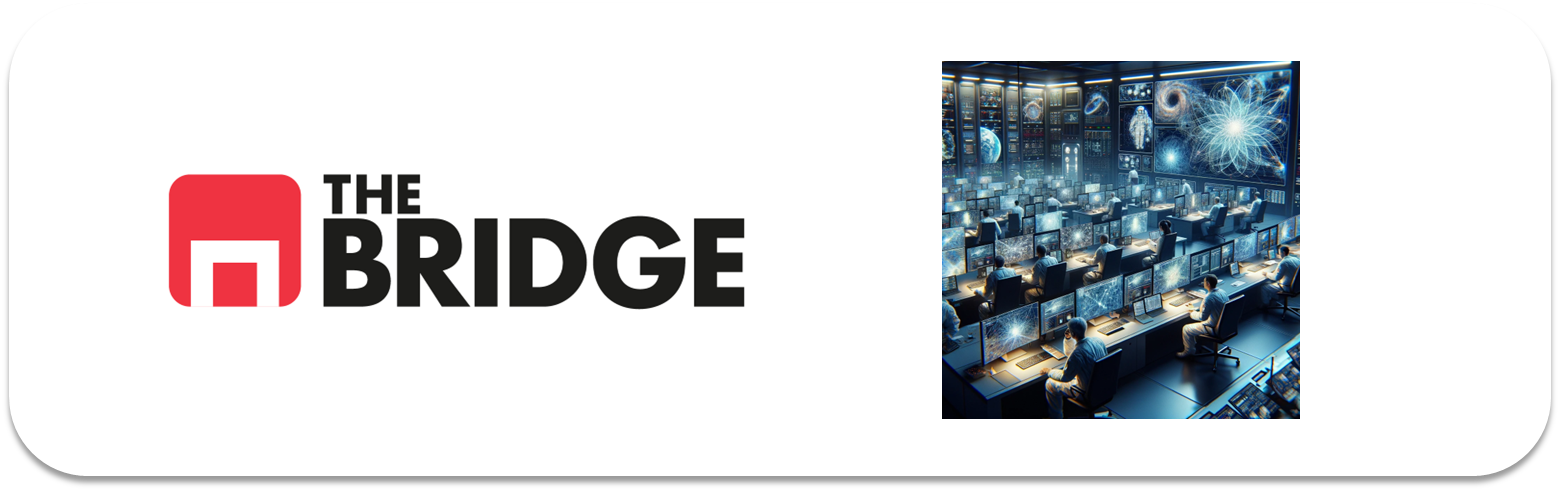

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import bootcampviztools as bt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

import warnings
warnings.filterwarnings("ignore")


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### Ejercicio 1: Carga de las imágenes (train y test)

Recorremos los cuatro directorios de train (`github_train_0` a `github_train_3`) y el directorio de test (`github_test`), leyendo cada imagen, redimensionándola a 32x32 y extrayendo la clase (`cat`/`dog`) a partir del nombre del fichero.

In [2]:
IMG_SIZE = (32, 32)

ROOT_PATH = "data/"
TRAIN_DIRS = [ROOT_PATH + d for d in ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]]
TEST_DIR = ROOT_PATH + "github_test"


def read_images_from_dirs(directorios, img_size=IMG_SIZE):
    X = []
    y = []
    for directorio in directorios:
        for file in os.listdir(directorio):
            image = cv2.imread(os.path.join(directorio, file))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, img_size)

            X.append(image)
            y.append("gato" if file.lower().startswith("cat") else "perro")

    return np.array(X), np.array(y)


X_train_raw, y_train_raw = read_images_from_dirs(TRAIN_DIRS)
X_test_raw, y_test_raw = read_images_from_dirs([TEST_DIR])

print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Test:", X_test_raw.shape, y_test_raw.shape)


Train: (4000, 32, 32, 3) (4000,)
Test: (1000, 32, 32, 3) (1000,)


### Visualización del dataset

Antes de nada echamos un ojo a algunas imágenes de cada clase y comprobamos que la carga y el redimensionado se ha hecho correctamente.

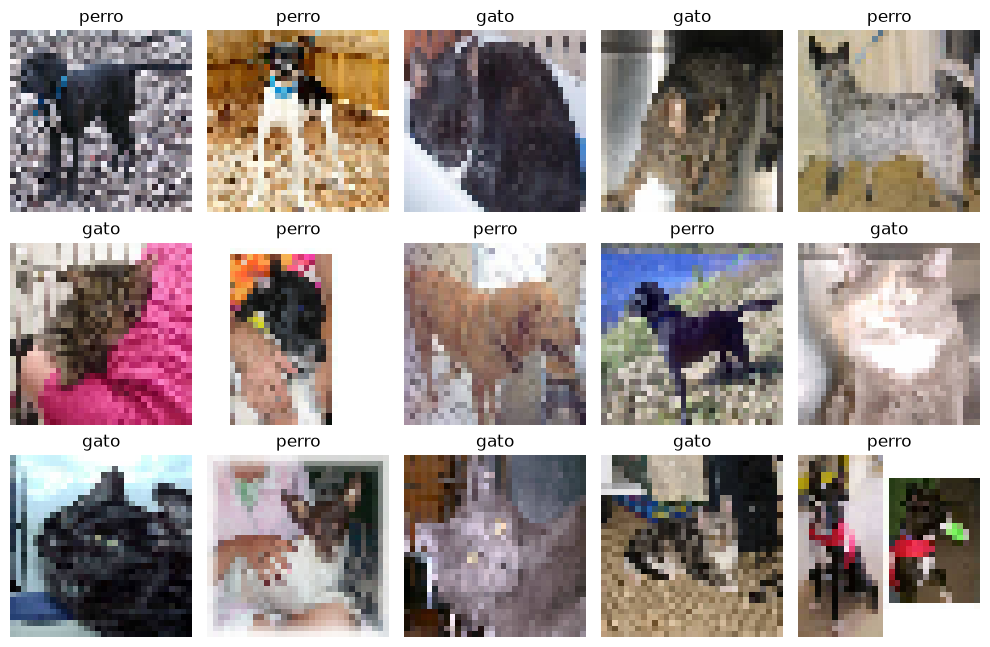

In [3]:
def plot_images(images, labels, n=15, n_cols=5):
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    idx = np.random.choice(len(images), size=n, replace=False)
    for i, index in enumerate(idx):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[index])
        plt.title(labels[index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_images(X_train_raw, y_train_raw, n=15)


### MiniEDA

Miramos el balance de clases (train y test) y el rango de valores de los píxeles antes de normalizar.

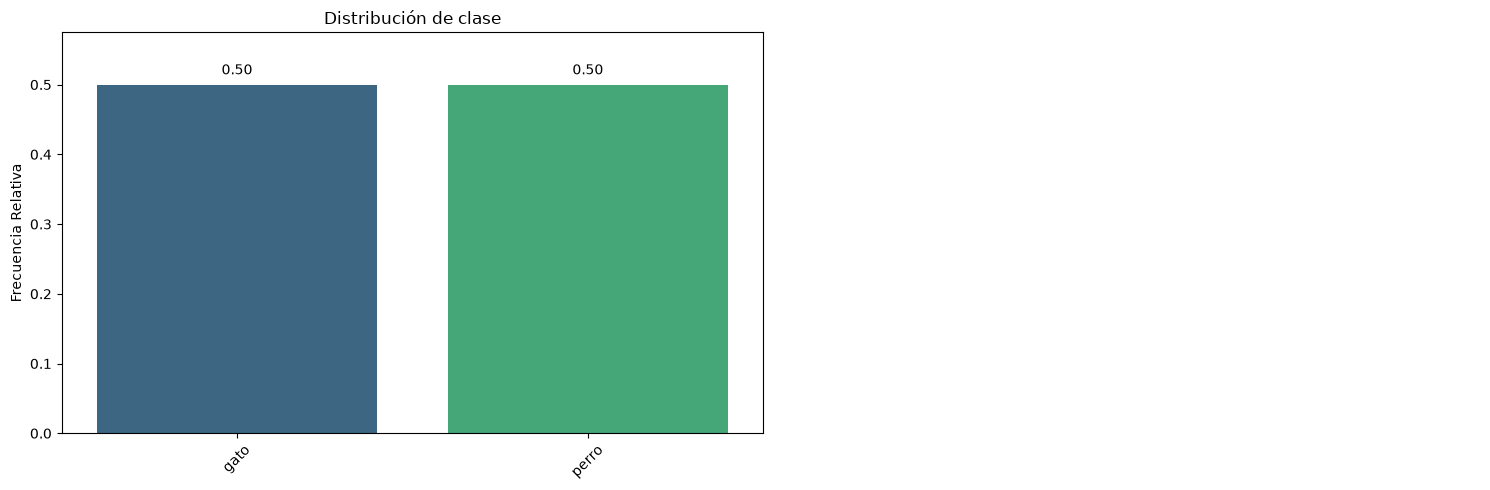

Rango de píxeles (train): 0 - 255
Dtype: uint8


In [4]:
bt.pinta_distribucion_categoricas(pd.DataFrame({"clase": y_train_raw}), ["clase"], True, True)

print("Rango de píxeles (train):", X_train_raw.min(), "-", X_train_raw.max())
print("Dtype:", X_train_raw.dtype)


Está bastante equilibrado en ambas clases. Toca ya normalizar (escalar por 255) y codificar la clase a un valor numérico (0 = gato, 1 = perro) para poder entrenar la red.

In [5]:
class_names = ["gato", "perro"]
label_map = {"gato": 0, "perro": 1}

X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

y_train = np.array([label_map[label] for label in y_train_raw])
y_test = np.array([label_map[label] for label in y_test_raw])

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(4000, 32, 32, 3) (4000,)
(1000, 32, 32, 3) (1000,)


### Ejercicio 2: Construcción del modelo

Montamos una red con dos bloques Convolucional-Pooling (con Dropout de regularización tras cada bloque) y una cabeza densa final, siguiendo el mismo esquema visto en el workout de la unidad pero adaptado a imágenes en color (32x32x3) y a un problema de clasificación binaria.

In [6]:
def build_model():
    model = Sequential()

    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPool2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation="softmax"))

    return model


model = build_model()

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,066 (2.08 MB)

 Trainable params: 544,066 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 3: Entrenamiento con EarlyStopping

Reservamos un 20% del train para validación y entrenamos con un callback de EarlyStopping que vigila la `val_loss` y recupera los mejores pesos.

In [7]:
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

batch_size = 32
epochs = 50
validation_split = 0.2

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
    callbacks=[early_stop],
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6141 - loss: 0.6839 - val_accuracy: 0.0000e+00 - val_loss: 0.8816
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6284 - loss: 0.6463 - val_accuracy: 0.1963 - val_loss: 0.7859
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6541 - loss: 0.6217 - val_accuracy: 0.2937 - val_loss: 0.8391
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6966 - loss: 0.5793 - val_accuracy: 0.5537 - val_loss: 0.7297
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7253 - loss: 0.5618 - val_accuracy: 0.5025 - val_loss: 0.7995
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7294 - loss: 0.5460 - val_accuracy: 0.7588 - val_loss: 0.5597
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7466 - loss: 0.5174 - val_accuracy: 0.6313 - val_loss: 0.6477
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7503 - loss: 0.5102 - val_

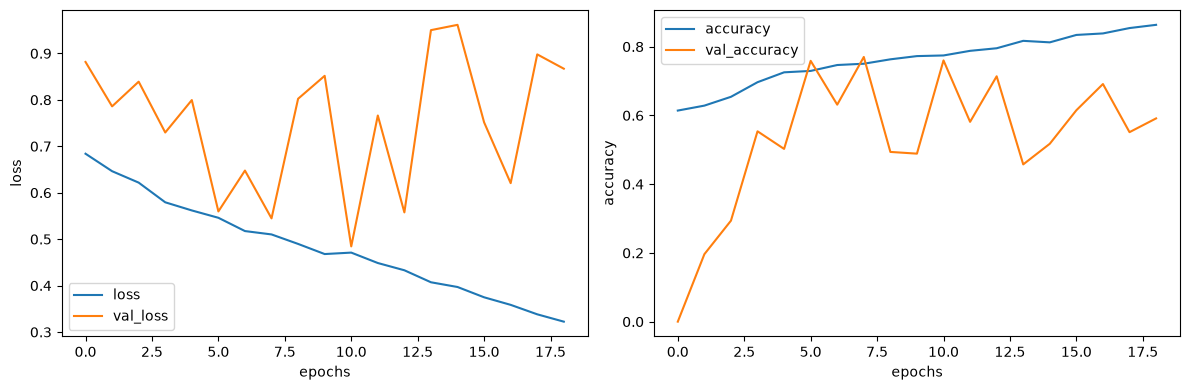

In [8]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()


### Ejercicio 4: Evaluación del modelo

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7430 - loss: 0.5366
Test loss: 0.5365564227104187
Test accuracy: 0.7429999709129333


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

        gato       0.76      0.71      0.73       500
       perro       0.73      0.78      0.75       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



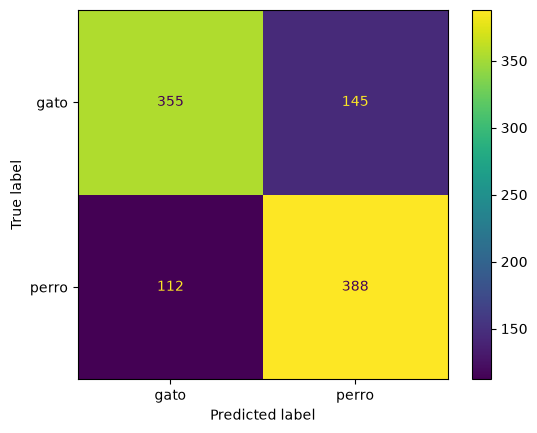

In [10]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names)
plt.show()


### Ejercicio 5: Selección de las imágenes más "difíciles"

De cada clase mal clasificada nos quedamos con el 10% de las imágenes en las que el modelo tenía mayor confianza (probabilidad) de que pertenecían a la clase errónea. Estas son las candidatas ideales para el nuevo CAPTCHA: las que más "engañan" a un clasificador automático.

In [11]:
confidence_pred = y_pred_probs[np.arange(len(y_pred_probs)), y_pred]

idx_gato_como_perro = np.where((y_test == 0) & (y_pred == 1))[0]
idx_perro_como_gato = np.where((y_test == 1) & (y_pred == 0))[0]


def top_n_percent(idx, confidences, pct=0.10):
    n = max(1, int(np.ceil(len(idx) * pct)))
    idx_ordenado = idx[np.argsort(-confidences[idx])]
    return idx_ordenado[:n]


top_gato_como_perro = top_n_percent(idx_gato_como_perro, confidence_pred)
top_perro_como_gato = top_n_percent(idx_perro_como_gato, confidence_pred)

print(f"Gatos mal clasificados: {len(idx_gato_como_perro)} -> seleccionados: {len(top_gato_como_perro)}")
print(f"Perros mal clasificados: {len(idx_perro_como_gato)} -> seleccionados: {len(top_perro_como_gato)}")

imagenes_captcha_idx = np.concatenate([top_gato_como_perro, top_perro_como_gato])


Gatos mal clasificados: 145 -> seleccionados: 15
Perros mal clasificados: 112 -> seleccionados: 12


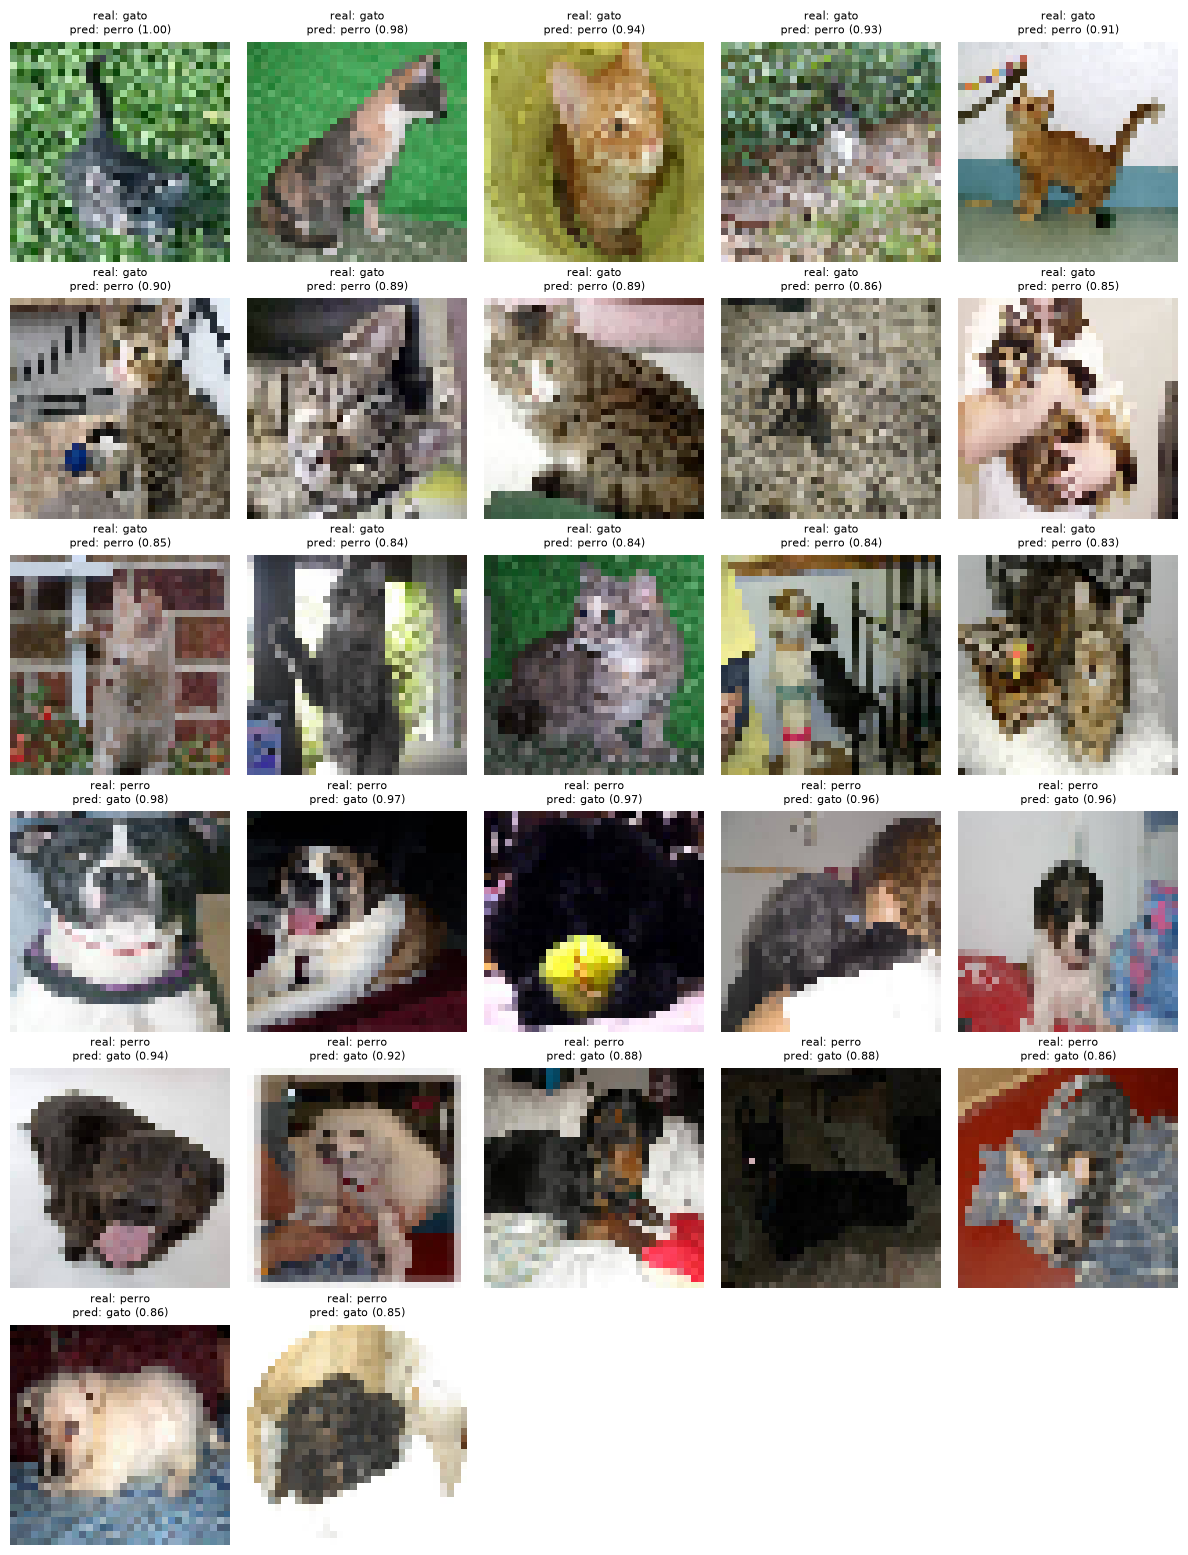

In [12]:
def plot_hardest(idx_list, images_raw, y_true, y_pred, confidences, n_cols=5):
    n = len(idx_list)
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2.4, n_rows * 2.6))
    for i, idx in enumerate(idx_list):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images_raw[idx])
        plt.title(
            f"real: {class_names[y_true[idx]]}\npred: {class_names[y_pred[idx]]} ({confidences[idx]:.2f})",
            fontsize=8,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_hardest(imagenes_captcha_idx, X_test_raw, y_test, y_pred, confidence_pred)


### Extra: repetir 3 a 5 con Image Augmentation

Reentrenamos la misma topología, pero esta vez el generador de `ImageDataGenerator` va creando variaciones (rotación, desplazamiento, zoom, flip horizontal) de las imágenes de train en cada batch para intentar mejorar la generalización.

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

train_generator = datagen.flow(X_tr, y_tr, batch_size=batch_size)

model_aug = build_model()
model_aug.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop_aug = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history_aug = model_aug.fit(
    train_generator,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_aug],
)


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4928 - loss: 0.7039 - val_accuracy: 0.5612 - val_loss: 0.6924
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5269 - loss: 0.6908 - val_accuracy: 0.5763 - val_loss: 0.6760
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5647 - loss: 0.6807 - val_accuracy: 0.5888 - val_loss: 0.6563
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6106 - loss: 0.6600 - val_accuracy: 0.6475 - val_loss: 0.6195
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6331 - loss: 0.6471 - val_accuracy: 0.6062 - val_loss: 0.6587
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6534 - loss: 0.6296 - val_accuracy: 0.6775 - val_loss: 0.5951
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6631 - loss: 0.6176 - val_accuracy: 0.6562 - val_loss: 0.6040
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6656 - loss: 0.6098 - val_accu

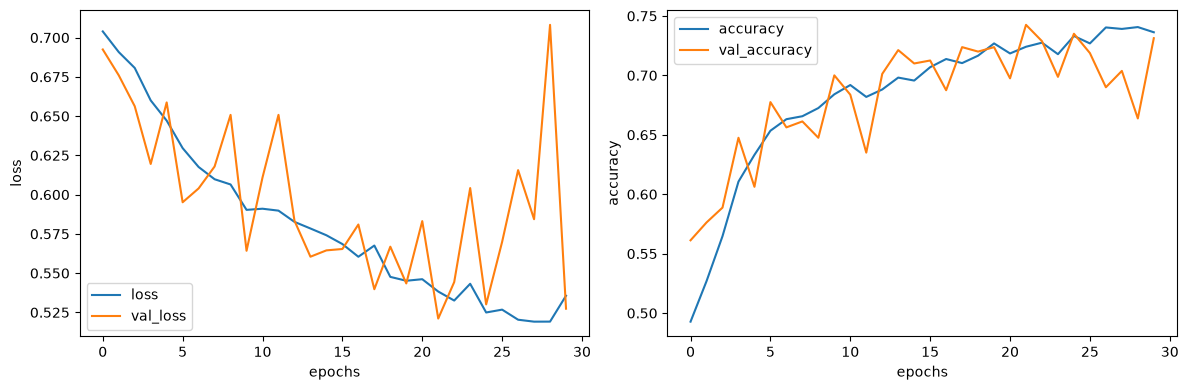

In [14]:
history_aug_df = pd.DataFrame(history_aug.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_aug_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

history_aug_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7390 - loss: 0.5132
Test loss (aug): 0.5131831169128418
Test accuracy (aug): 0.7390000224113464
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

        gato       0.77      0.68      0.72       500
       perro       0.72      0.79      0.75       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000



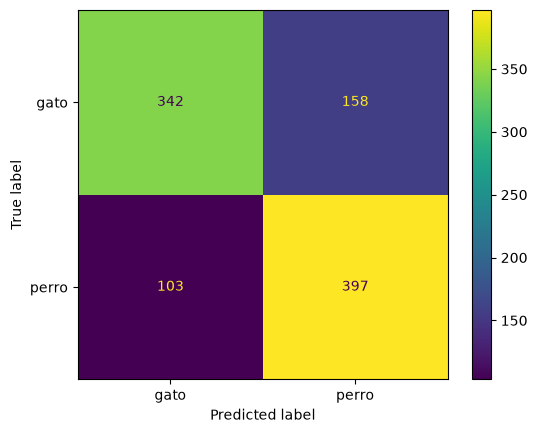

In [15]:
test_loss_aug, test_accuracy_aug = model_aug.evaluate(X_test, y_test)
print("Test loss (aug):", test_loss_aug)
print("Test accuracy (aug):", test_accuracy_aug)

y_pred_probs_aug = model_aug.predict(X_test)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)

print(classification_report(y_test, y_pred_aug, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_aug, display_labels=class_names)
plt.show()


Gatos mal clasificados (aug): 158 -> seleccionados: 16
Perros mal clasificados (aug): 103 -> seleccionados: 11


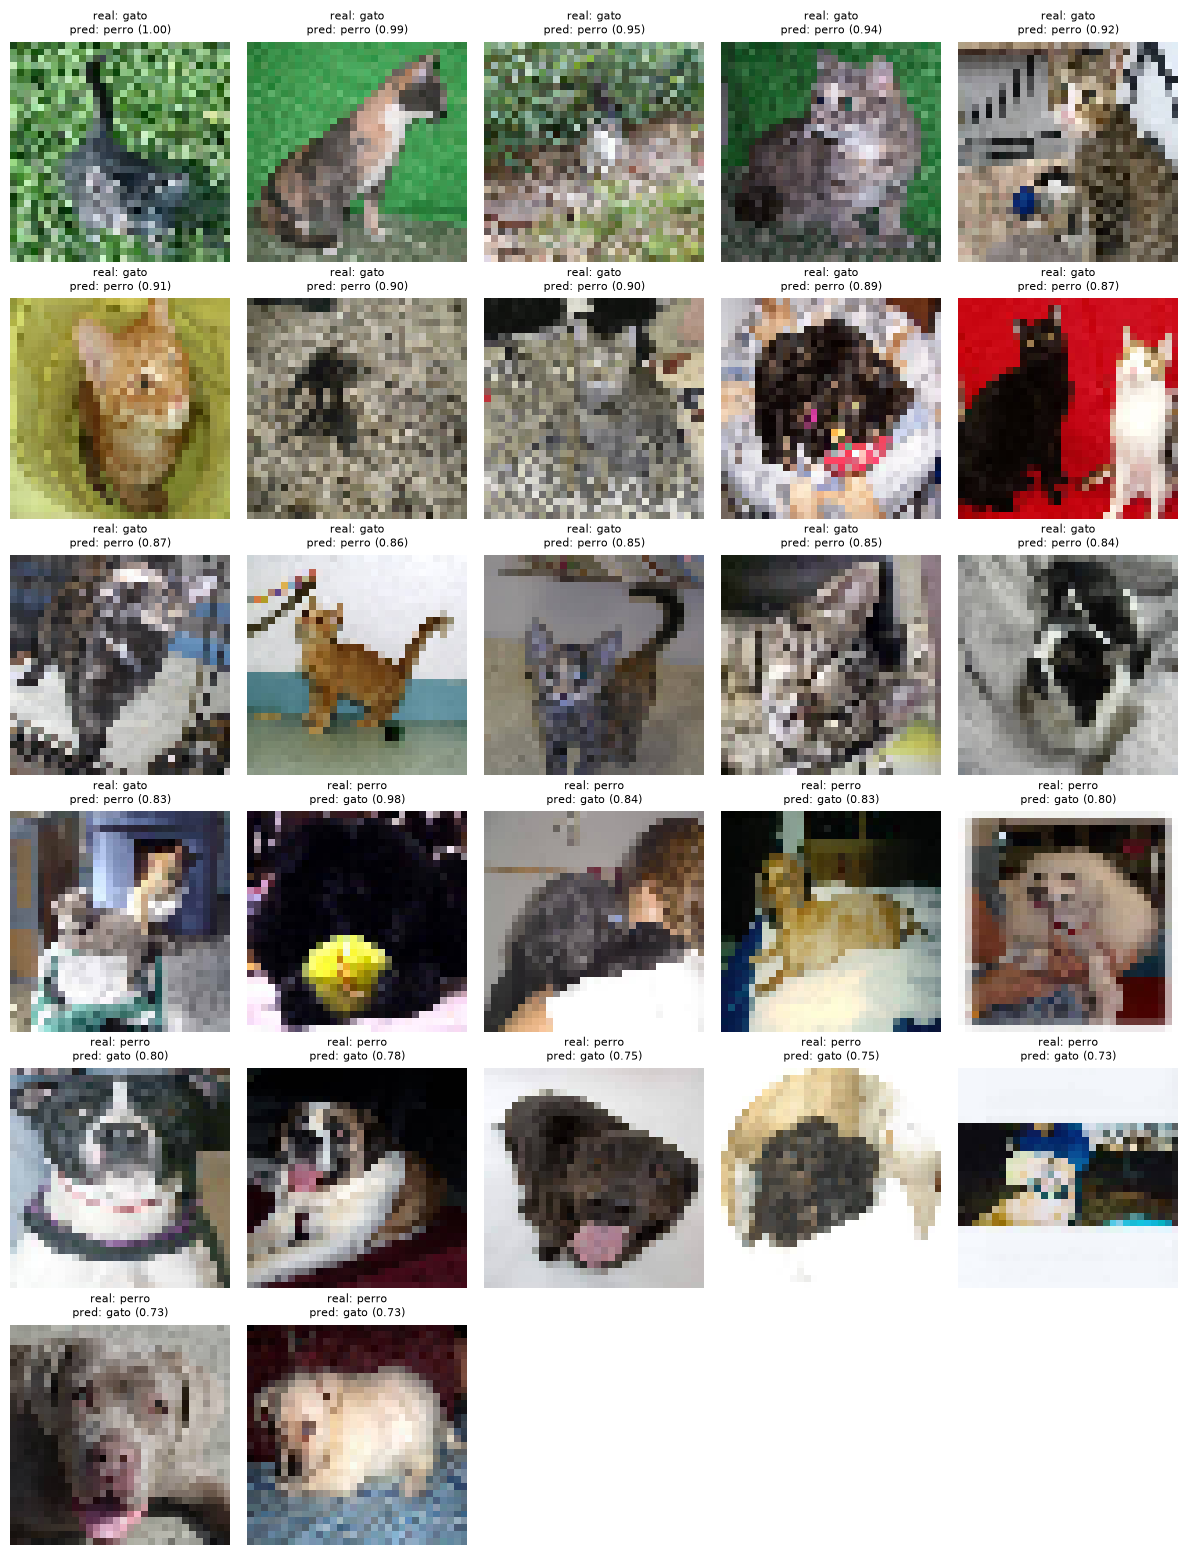

In [16]:
confidence_pred_aug = y_pred_probs_aug[np.arange(len(y_pred_probs_aug)), y_pred_aug]

idx_gato_como_perro_aug = np.where((y_test == 0) & (y_pred_aug == 1))[0]
idx_perro_como_gato_aug = np.where((y_test == 1) & (y_pred_aug == 0))[0]

top_gato_como_perro_aug = top_n_percent(idx_gato_como_perro_aug, confidence_pred_aug)
top_perro_como_gato_aug = top_n_percent(idx_perro_como_gato_aug, confidence_pred_aug)

print(f"Gatos mal clasificados (aug): {len(idx_gato_como_perro_aug)} -> seleccionados: {len(top_gato_como_perro_aug)}")
print(f"Perros mal clasificados (aug): {len(idx_perro_como_gato_aug)} -> seleccionados: {len(top_perro_como_gato_aug)}")

imagenes_captcha_idx_aug = np.concatenate([top_gato_como_perro_aug, top_perro_como_gato_aug])

plot_hardest(imagenes_captcha_idx_aug, X_test_raw, y_test, y_pred_aug, confidence_pred_aug)
